# NLP Task
# Rating Prediction using Hotel Review Dataset

**Module:** Artificial Intelligence and Machine Learning  
**Institution:** Herald College Kathmandu  
**Submitted Date:** May 10, 2026

---

| Name | ID Number | Group |
| :--- | :--- | :--- |
| **Narayan Lohani** | 2408869 | L6CG15 |

---

<div style="display:flex;justify-content:space-between;align-items:center;border:none;">
  <img src="https://heraldcollege.edu.np/images/footer/footer-logo-dark.svg" width="180" alt="Herald College Logo">
  <img src="https://bizzeducation.com/storage/university-partners/May2024/r3iG0n8CHfh1nCAIz5BO.png" width="180" alt="University of Wolverhampton Logo">
</div>


## 🔗 Mount Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


## 📦 0. Install & Import Dependencies

All required packages are installed here. Key libraries:
- **wordcloud / contractions**: text visualisation and contraction expansion  
- **gensim**: downloading pre-trained GloVe / Word2Vec vectors  
- **gradio**: building the real-time prediction GUI (Task 4.5.5)


In [2]:
import os

!pip install -q wordcloud contractions gradio gensim nltk


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.1 MB/s eta 0:00:00


In [ ]:
# ── Standard Library & Utilities ─────────────────────────────────────────────
import re
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings("ignore")

# ── NLP & Text Processing ────────────────────────────────────────────────────
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import gensim.downloader as gensim_dl

# NLTK Downloads
for pkg in ["stopwords", "wordnet", "omw-1.4", "punkt"]:
    nltk.download(pkg, quiet=True)

# ── Machine Learning (Scikit-Learn) ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Deep Learning (TensorFlow / Keras) ───────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization,
    Bidirectional,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print("All libraries loaded successfully! ✓")


TensorFlow  : 2.20.0
NumPy       : 2.0.2
All libraries loaded successfully! ✓


---
## 4.5.1: Text Preprocessing, Tokenisation, and Sequence Padding

This section covers the full preprocessing pipeline required before any model can consume raw text:

1. **Load** the raw Hotel Reviews CSV  
2. **Clean** each review (lowercase, remove noise, expand contractions, lemmatise)  
3. **Visualise** the vocabulary with a word cloud and frequency bar chart  
4. **Split** into train/test sets (80/20, stratified by rating)  
5. **Tokenise** using Keras `Tokenizer` and **pad** to a percentile-based fixed length


### 4.5.1.1: Load Dataset

In [ ]:
# ── Load the Hotel Reviews dataset ───────────────────────────────────────────
AI_FOLDER_PATH = "/content/drive/MyDrive/ai/ai - assessment: Group A/"
DATASET_NAME = "Hotel_Reviews.csv"

DATA_PATH = os.path.join(AI_FOLDER_PATH, DATASET_NAME)

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {df.columns.tolist()}")
print(f"\nRating distribution:")
print(df["Rating"].value_counts().sort_index())
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head()


/content/drive/MyDrive/ai/ai - assessment: Group A/Hotel_Reviews.csv
Dataset shape : (20491, 2)
Columns       : ['Review', 'Rating']

Rating distribution:
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Missing values:
Review    0
Rating    0
dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### 4.5.1.2: Text Cleaning Function

**Design rationale:**

| Step | Justification |
|------|---------------|
| Contraction expansion (`don't` → `do not`) | Prevents the tokeniser from creating separate OOV tokens for contracted forms |
| Lowercase | Ensures `Hotel` and `hotel` map to the same token |
| Remove URLs / mentions / hashtags | Noise irrelevant to hotel sentiment |
| Remove digits | Star counts written as numbers add no signal once we normalise labels |
| Remove special chars | Punctuation is not used in this bag-of-tokens approach |
| Remove stopwords (with negation preserved) | Function words inflate vocabulary without adding meaning; *however*, negation words (`not`, `no`, `never`, `but`, etc.) are **kept** because they flip sentiment polarity |
| Lemmatise (verb form) | Reduces `staying` / `stayed` / `stays` to `stay`, shrinking vocabulary |


In [ ]:
STOP_WORDS = set(stopwords.words("english"))

# Preserve negation words as they are critical for sentiment polarity.
NEGATION_WORDS = {
    "not",
    "no",
    "nor",
    "never",
    "but",
    "without",
    "nobody",
    "nothing",
    "nowhere",
    "neither",
    "hardly",
    "barely",
    "scarcely",
    "don",
    "didn",
    "doesn",
    "isn",
    "wasn",
    "aren",
    "weren",
    "haven",
    "hasn",
    "hadn",
    "won",
    "wouldn",
    "couldn",
    "shouldn",
    "mustn",
}
STOP_WORDS -= NEGATION_WORDS

lemmatizer = WordNetLemmatizer()


def clean_text(text: str) -> str:
    """Full NLP preprocessing pipeline for a single review string."""
    text = contractions.fix(text)  # 1. Expand contractions
    text = text.lower()  # 2. Lowercase
    text = re.sub(r"https?://\S+|www\.\S+", "", text)  # 3. Remove URLs
    text = re.sub(r"@\w+|#\w+", "", text)  # 4. Remove mentions/hashtags
    text = re.sub(r"\d+", "", text)  # 5. Remove digits
    text = re.sub(r"[^a-z\s]", "", text)  # 6. Remove special chars
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(tok, pos="v")
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 1
    ]
    return " ".join(tokens)


df["clean_review"] = df["Review"].apply(clean_text)

# original vs cleaned
print("Original :", df["Review"].iloc[0])
print("Cleaned  :", df["clean_review"].iloc[0])
print(f"\nEmpty reviews after cleaning: {(df['clean_review'].str.strip() == '').sum()}")


Original : nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick easy, little disappointed non-existent view room room clean nice size, bed comfortable woke stiff neck high pillows, not soundproof like heard music room night morning loud bangs doors opening closing hear people talking hallway, maybe just noisy neighbors, aveda bath products nice, did not goldfish stay nice touch taken advantage staying longer, location great walking distance shopping, overall nice experience having pay 40 parking night,  
Cleaned  : nice hotel expensive park get good deal stay hotel anniversary arrive late even take advice previous review valet park check quick easy little disappoint nonexistent view room room clean nice size bed comfortable wake stiff neck high pillow not soundproof like hear music room night morning loud bang doors open close hear people talk hallway maybe noisy neighbor aveda bath products 

### 4.5.1.3: Visualise Cleaned Data

A **word cloud** gives an intuitive feel for the most prominent terms, while the **top-30 frequency bar chart** provides precise counts. Both help verify that preprocessing removed noise without destroying domain vocabulary.


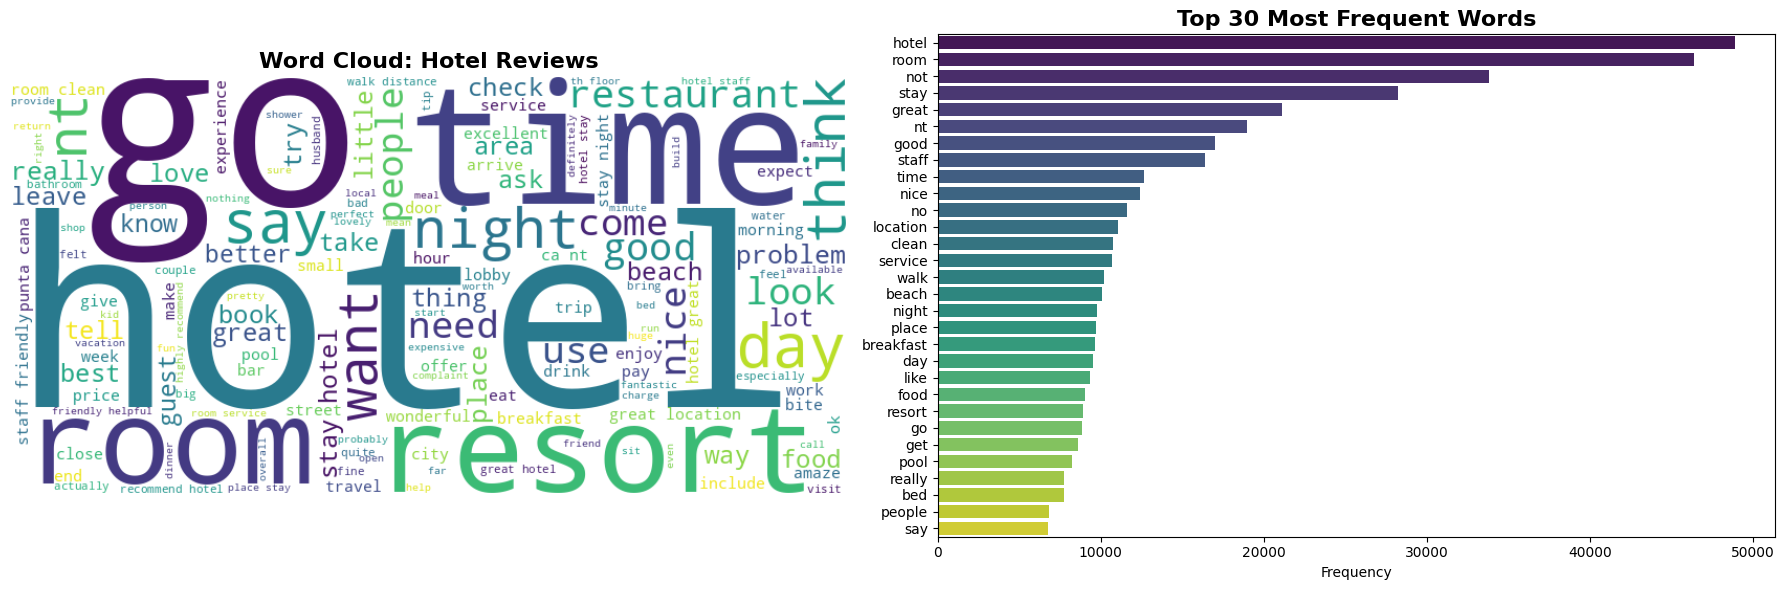

Unique vocabulary size after cleaning: 68,843


In [ ]:
all_words = " ".join(df["clean_review"])
word_freq = Counter(all_words.split())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Word Cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(
    width=800, height=400, background_color="white", colormap="viridis", max_words=150
).generate(all_words)

axes[0].imshow(wc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Hotel Reviews", fontsize=16, fontweight="bold")

# ── Top-30 Frequency Bar Chart ────────────────────────────────────────────────
top_words = pd.DataFrame(word_freq.most_common(30), columns=["Word", "Count"])
sns.barplot(data=top_words, x="Count", y="Word", palette="viridis", ax=axes[1])
axes[1].set_title("Top 30 Most Frequent Words", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()
print(f"Unique vocabulary size after cleaning: {len(word_freq):,}")


### 4.5.1.4: Train / Test Split (80 / 20, stratified)

In [ ]:
# 0-indexed labels: {0, 1, 2, 3, 4}
df["label"] = df["Rating"] - 1
NUM_CLASSES = df["label"].nunique()

X = df["clean_review"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nClass distribution in training set:")
for c, n in zip(*np.unique(y_train, return_counts=True)):
    print(f"  Rating {c+1}: {n:,} ({n/len(y_train)*100:.1f}%)")


Training samples : 16,392
Test samples     : 4,099
Number of classes: 5

Class distribution in training set:
  Rating 1: 1,137 (6.9%)
  Rating 2: 1,434 (8.7%)
  Rating 3: 1,747 (10.7%)
  Rating 4: 4,831 (29.5%)
  Rating 5: 7,243 (44.2%)


### 4.5.1.5: Keras Tokeniser & Percentile-Based Padding

**Vocabulary size (10,000):** The most frequent 10 k tokens cover the vast majority of hotel vocabulary. Rarer words (typos, proper nouns) are mapped to `<OOV>`.

**Percentile-based MAX_LEN:** Using the 90th-percentile sequence length avoids padding every sequence to the length of the longest outlier review. This keeps memory usage manageable and prevents padded zeros from dominating the recurrent computation.


Sequence length statistics (train):
  min  = 8
  mean = 99.6
  90th pct (MAX_LEN) = 191
  max  = 1886


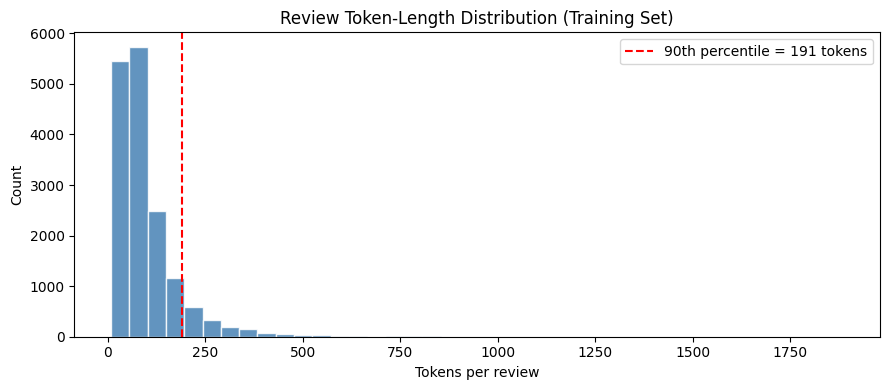


X_train_pad shape : (16392, 191)
X_test_pad  shape : (4099, 191)

Class weights: {0: np.float64(2.883), 1: np.float64(2.286), 2: np.float64(1.877), 3: np.float64(0.679), 4: np.float64(0.453)}


In [ ]:
VOCAB_SIZE = 10_000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)  # fit ONLY on training data to avoid leakage

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# ── Percentile-based sequence length ─────────────────────────────────────────
train_lengths = [len(s) for s in train_sequences]
PERCENTILE = 90
MAX_LEN = int(np.percentile(train_lengths, PERCENTILE))

print("Sequence length statistics (train):")
print(f"  min  = {min(train_lengths)}")
print(f"  mean = {np.mean(train_lengths):.1f}")
print(f"  {PERCENTILE}th pct (MAX_LEN) = {MAX_LEN}")
print(f"  max  = {max(train_lengths)}")

# ── Length distribution plot ──────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.hist(train_lengths, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
plt.axvline(
    MAX_LEN,
    color="red",
    linestyle="--",
    label=f"{PERCENTILE}th percentile = {MAX_LEN} tokens",
)
plt.title("Review Token-Length Distribution (Training Set)")
plt.xlabel("Tokens per review")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# ── Pad / truncate sequences ──────────────────────────────────────────────────
X_train_pad = pad_sequences(
    train_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    test_sequences, maxlen=MAX_LEN, padding="post", truncating="post"
)

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

# ── Class weights (counter class imbalance) ───────────────────────────────────
cw_arr = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
CLASS_WEIGHTS = dict(enumerate(cw_arr))
print(f"\nClass weights: { {k: round(v,3) for k,v in CLASS_WEIGHTS.items()} }")

# ── One-hot encode labels for categorical_crossentropy ────────────────────────
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)


---
## 4.5.2: Model Building

Three models are built, each adding complexity over the previous:

| Model | Recurrent Layer | Embedding |
|-------|----------------|-----------|
| 1. Simple RNN | Bidirectional SimpleRNN | Trainable (random init, 128d) |
| 2. LSTM | Stacked Bidirectional LSTM | Trainable (random init, 128d) |
| 3. LSTM + GloVe | Stacked Bidirectional LSTM | Pre-trained GloVe-Twitter-100 (fine-tuned) |

All models share the same output head: `Dense(64, relu) → Dense(5, softmax)`.


### 4.5.2.1: Shared Hyperparameters & Callbacks

In [ ]:
EMBED_DIM = 128
RNN_UNITS = 128
LSTM_UNITS = 128
DROPOUT_R = 0.4
BATCH_SIZE = 64
EPOCHS = 30

os.makedirs("models", exist_ok=True)  # directory for saved checkpoints


def make_callbacks(model_name: str):
    """Return EarlyStopping + ModelCheckpoint + ReduceLROnPlateau callbacks."""
    es = EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
    )
    ckpt = ModelCheckpoint(
        filepath=f"models/best_{model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0,
    )
    rlr = ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
    return [es, ckpt, rlr]


### 4.5.2.2: Model 1: Simple RNN

**Architecture rationale:**  
A `Bidirectional(SimpleRNN)` reads each review in both directions, helping it capture negations that appear *before* the sentiment adjective (e.g., "not great"). `SpatialDropout1D` drops entire embedding dimensions during training, which is more effective than elementwise dropout for sequential data. A `BatchNormalization` layer stabilises the activations coming out of the recurrent block.

**Limitation:** SimpleRNN suffers from vanishing gradients on long sequences, so this model is expected to underperform on lengthy, nuanced reviews.


In [ ]:
def build_simple_rnn():
    """
    Bidirectional SimpleRNN.
    Wrapping in Bidirectional doubles the effective units and lets the model
    read the review from both ends, helping capture late-appearing negations.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(
                SimpleRNN(units=RNN_UNITS, return_sequences=False), name="simple_rnn"
            ),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model1_Bi_SimpleRNN",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model1 = build_simple_rnn()
model1.summary()


Model: "Model1_Bi_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (Bidirectional)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.3: Model 2: LSTM

**Architecture rationale:**  
LSTM's gating mechanism (`input`, `forget`, `output` gates) solves the vanishing-gradient problem, enabling the model to retain long-range dependencies across a review. Two stacked `Bidirectional LSTM` layers are used: the first returns sequences so the second can process the full temporal context. The second layer halves the units to create an information bottleneck.


In [ ]:
def build_lstm():
    """
    Stacked Bidirectional LSTM.
    - Two Bi-LSTM layers: the first returns sequences so the second can process the full temporal output, not just the final hidden state.
    - BatchNormalization after the recurrent block stabilises training.
    - Extra Dense(64) hidden layer before the softmax head.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=EMBED_DIM,
                input_length=MAX_LEN,
                name="embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(
                LSTM(units=LSTM_UNITS, return_sequences=True), name="bi_lstm_1"
            ),
            Bidirectional(LSTM(units=LSTM_UNITS // 2), name="bi_lstm_2"),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model2_Stacked_BiLSTM",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model2 = build_lstm()
model2.summary()


Model: "Model2_Stacked_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.5.2.4: Model 3: LSTM + Pre-trained GloVe Embeddings

**Pre-trained embedding rationale:**  
GloVe (Global Vectors for Word Representation) encodes co-occurrence statistics from a large external corpus. Using `glove-twitter-100` gives the model semantic relationships (e.g., *excellent* ≈ *outstanding*) **before** any training on hotel reviews. A **two-phase** fine-tuning strategy is used:
1. **Warm-up (5 epochs, frozen embeddings):** The LSTM learns to route information using the GloVe vectors without distorting them.  
2. **Fine-tune (full EPOCHS, unfrozen, LR × 0.1):** The embeddings adapt gently to hotel-review vocabulary while the trained LSTM provides stable gradients.


In [ ]:
print("Downloading GloVe-Twitter-100 vectors (≈ 400 MB, one-time) …")
glove_model = gensim_dl.load("glove-twitter-100")
GLOVE_DIM = 100  # must match the loaded model
print(f"GloVe loaded, vocabulary size: {len(glove_model):,}")


[==================================================] 100.0% 387.1/387.1MB downloaded
GloVe loaded, vocabulary size: 1,193,514


In [ ]:
word_index = tokenizer.word_index
hits, misses = 0, 0

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        hits += 1
    else:
        # Random small init for OOV words
        embedding_matrix[idx] = np.random.normal(scale=0.1, size=GLOVE_DIM)
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"GloVe coverage  : {hits:,}/{hits+misses:,} tokens ({coverage:.1f}%)")
print(f"Embedding matrix: {embedding_matrix.shape}")


GloVe coverage  : 9,079/9,999 tokens (90.8%)
Embedding matrix: (10000, 100)


In [ ]:
def build_lstm_glove():
    """
    GloVe embedding fine-tuning strategy.
    - Start frozen (trainable=False) for the first phase so the LSTM learns
      to use the GloVe vectors without corrupting them immediately.
    - After warm-up training (below), set trainable=True and re-compile with
      a very low learning rate so the embeddings adapt gently.
    - Stacked Bi-LSTM + hidden Dense for full parity with Model 2.
    """
    model = Sequential(
        [
            Embedding(
                input_dim=VOCAB_SIZE,
                output_dim=GLOVE_DIM,
                input_length=MAX_LEN,
                weights=[embedding_matrix],
                trainable=False,  # frozen during warm-up
                name="glove_embedding",
            ),
            SpatialDropout1D(DROPOUT_R),
            Bidirectional(
                LSTM(units=LSTM_UNITS, return_sequences=True), name="bi_lstm_1"
            ),
            Bidirectional(LSTM(units=LSTM_UNITS // 2), name="bi_lstm_2"),
            BatchNormalization(),
            Dropout(DROPOUT_R),
            Dense(64, activation="relu", name="hidden"),
            Dropout(DROPOUT_R),
            Dense(NUM_CLASSES, activation="softmax", name="output"),
        ],
        name="Model3_BiLSTM_GloVe",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model3 = build_lstm_glove()
model3.summary()


Model: "Model3_BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_1 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm_2 (Bidirectional)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

---
## 4.5.3: Model Training and Evaluation

### Training Configuration

| Setting | Value | Rationale |
|---------|-------|-----------|
| Loss | `categorical_crossentropy` | Multi-class (5 classes), one-hot labels |
| Optimiser | Adam (lr=1e-3) | Adaptive learning rate; robust default |
| Epochs | 30 (early stopping) | Prevents over-training; patience=5 restores best weights |
| Batch size | 64 | Memory-efficient; good gradient estimate |
| Class weights | Balanced | Hotel reviews skew heavily towards 5-star ratings |


### 4.5.3.1: Train Model 1: Simple RNN

In [ ]:
history1 = model1.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model1_rnn"),
    verbose=1,
)


Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.3393 - loss: 1.6040 - val_accuracy: 0.1356 - val_loss: 1.8571 - learning_rate: 0.0010
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.4740 - loss: 1.2576 - val_accuracy: 0.4418 - val_loss: 8.6167 - learning_rate: 0.0010
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5246 - loss: 1.1443 - val_accuracy: 0.4523 - val_loss: 2.6788 - learning_rate: 0.0010
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4894 - loss: 1.2527 - val_accuracy: 0.5238 - val_loss: 1.2113 - learning_rate: 0.0010
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5399 - loss: 1.0903 - val_accuracy: 0.2052 - val_loss: 1.8911 - learning_rate: 0.0010
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5819 - loss: 0.9888 - val_accuracy: 0.5431 - val_loss: 1.0763 - learning_rate: 0.0010
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.6172 - loss: 0

### 4.5.3.2: Train Model 2: LSTM

In [ ]:
history2 = model2.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model2_lstm"),
    verbose=1,
)


Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.4334 - loss: 1.3059 - val_accuracy: 0.5235 - val_loss: 1.1774 - learning_rate: 0.0010
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.5780 - loss: 1.0059 - val_accuracy: 0.4545 - val_loss: 1.3115 - learning_rate: 0.0010
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6213 - loss: 0.8786 - val_accuracy: 0.4970 - val_loss: 1.1885 - learning_rate: 0.0010
Epoch 4/30
256/257 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6519 - loss: 0.7923
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6614 - loss: 0.7575 - val_accuracy: 0.5284 - val_loss: 1.4804 - learning_rate: 0.0010
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.7059 - loss: 0.6275 - val_accuracy: 0.5294 - val_loss: 1.9778 - learning_rate: 5.0000e-04
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7352 -

### 4.5.3.3: Train Model 3: LSTM + GloVe (two-phase)

In [ ]:
# ── Phase 1: Frozen embedding warm-up (5 epochs) ────────────────────────────
print("=" * 60)
print("Phase 1 : Warm-up: GloVe embeddings frozen")
print("=" * 60)
history3_warmup = model3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=5,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    verbose=1,
)

# ── Phase 2 : Unfreeze + fine-tune at lower LR ────────────────────────────────
print("\n" + "=" * 60)
print("Phase 2 : Fine-tuning: Glove embeddings unfrozen")
print("=" * 60)
model3.layers[0].trainable = True  # glove_embedding layer
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history3 = model3.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks("model3_glove"),
    verbose=1,
)


Phase 1 : Warm-up: GloVe embeddings frozen
Epoch 1/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.3333 - loss: 1.6761 - val_accuracy: 0.4369 - val_loss: 1.4092
Epoch 2/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.4428 - loss: 1.3014 - val_accuracy: 0.5636 - val_loss: 1.0656
Epoch 3/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.4887 - loss: 1.2029 - val_accuracy: 0.5697 - val_loss: 0.9961
Epoch 4/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5208 - loss: 1.1368 - val_accuracy: 0.5801 - val_loss: 0.9212
Epoch 5/5
257/257 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.5378 - loss: 1.0909 - val_accuracy: 0.5787 - val_loss: 0.9472

Phase 2 : Fine-tuning: Glove embeddings unfrozen
Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.5649 - loss: 1.0481 - val_accuracy: 0.5853 - val_loss: 0.9178 - learning_rate: 1.0000e-04
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.5734 - loss: 1.0228 - val_accuracy: 

### 4.5.3.4: Training Curves: Loss & Accuracy (All Three Models)

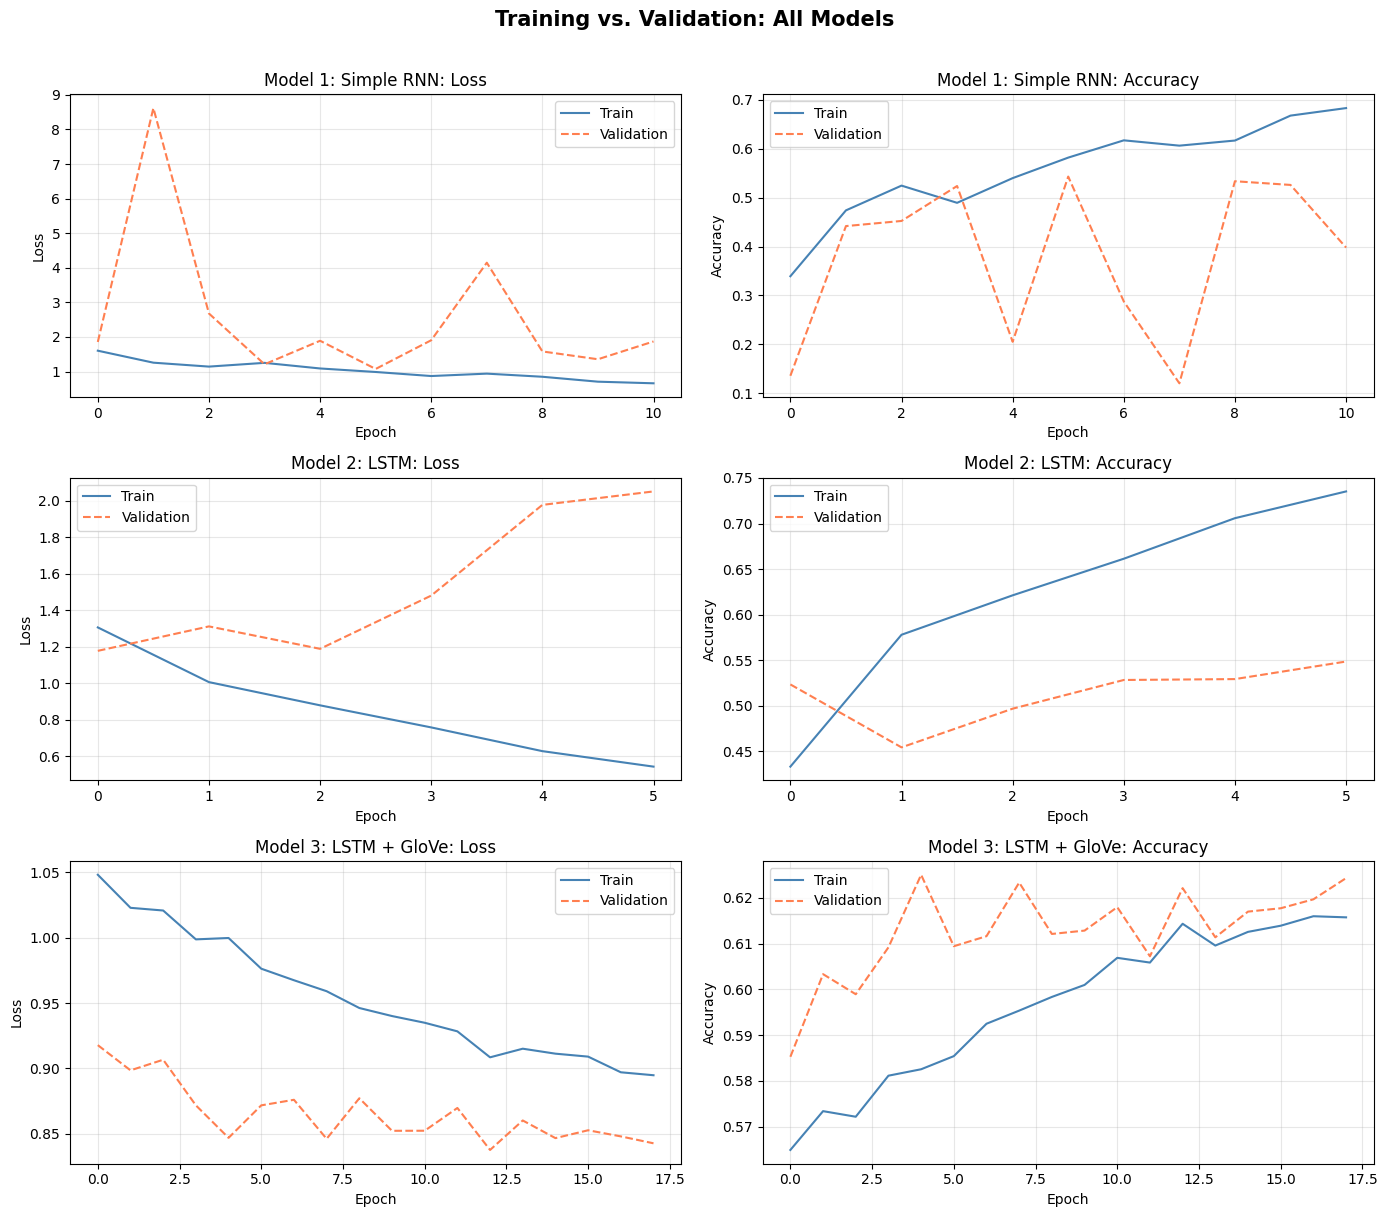

In [ ]:
def plot_history(histories, names):
    """Plot loss and accuracy curves for multiple Keras History objects."""
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))

    for i, (hist, name) in enumerate(zip(histories, names)):
        h = hist.history
        ax_loss, ax_acc = axes[i, 0], axes[i, 1]

        ax_loss.plot(h["loss"], label="Train", color="steelblue")
        ax_loss.plot(h["val_loss"], label="Validation", color="coral", linestyle="--")
        ax_loss.set_title(f"{name}: Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()
        ax_loss.grid(alpha=0.3)

        ax_acc.plot(h["accuracy"], label="Train", color="steelblue")
        ax_acc.plot(
            h["val_accuracy"], label="Validation", color="coral", linestyle="--"
        )
        ax_acc.set_title(f"{name}: Accuracy")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()
        ax_acc.grid(alpha=0.3)

    plt.suptitle(
        "Training vs. Validation: All Models", fontsize=15, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()


plot_history(
    [history1, history2, history3],
    ["Model 1: Simple RNN", "Model 2: LSTM", "Model 3: LSTM + GloVe"],
)


---
## 4.5.4: Model Evaluation

Each model is evaluated using three complementary metrics:
1. **Accuracy**: overall fraction of correct predictions
2. **Confusion Matrix** (normalised): reveals *which* classes are confused with each other  
3. **Classification Report**: per-class precision, recall, and F1-score

### 4.5.4.1: Confusion Matrix & Classification Report



═════════════════════════════════════════════════════════════════
  Model 1: Simple RNN  |  Test Accuracy: 0.5431 (54.31%)
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.36      0.71      0.48       284
    Rating 2       0.36      0.32      0.34       359
    Rating 3       0.31      0.37      0.34       437
    Rating 4       0.57      0.20      0.29      1208
    Rating 5       0.66      0.83      0.74      1811

    accuracy                           0.54      4099
   macro avg       0.45      0.49      0.44      4099
weighted avg       0.55      0.54      0.51      4099



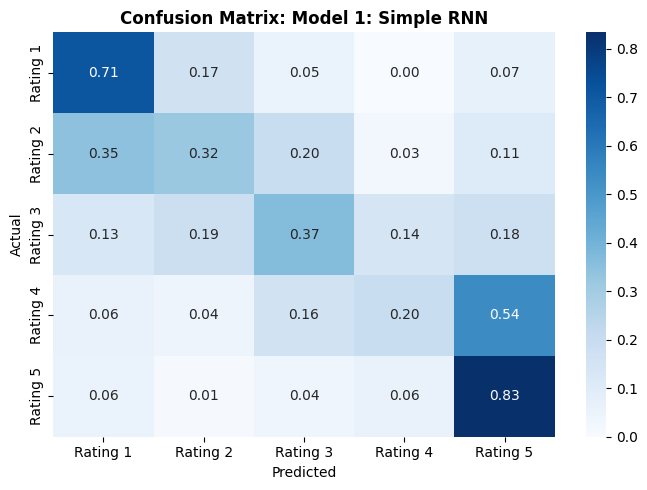


═════════════════════════════════════════════════════════════════
  Model 2: LSTM  |  Test Accuracy: 0.5235 (52.35%)
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.90      0.07      0.12       284
    Rating 2       0.00      0.00      0.00       359
    Rating 3       0.16      0.08      0.10       437
    Rating 4       0.38      0.42      0.40      1208
    Rating 5       0.63      0.87      0.73      1811

    accuracy                           0.52      4099
   macro avg       0.41      0.29      0.27      4099
weighted avg       0.47      0.52      0.46      4099



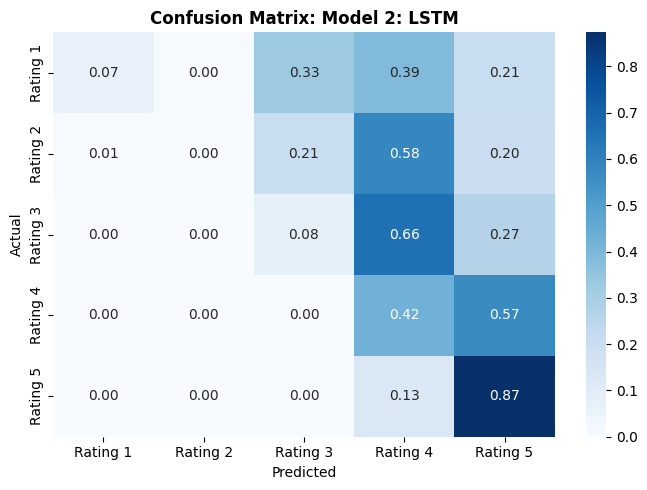


═════════════════════════════════════════════════════════════════
  Model 3: LSTM + GloVe  |  Test Accuracy: 0.6221 (62.21%)
═════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Rating 1       0.67      0.71      0.69       284
    Rating 2       0.47      0.50      0.49       359
    Rating 3       0.37      0.50      0.43       437
    Rating 4       0.56      0.46      0.50      1208
    Rating 5       0.76      0.77      0.77      1811

    accuracy                           0.62      4099
   macro avg       0.57      0.59      0.57      4099
weighted avg       0.63      0.62      0.62      4099



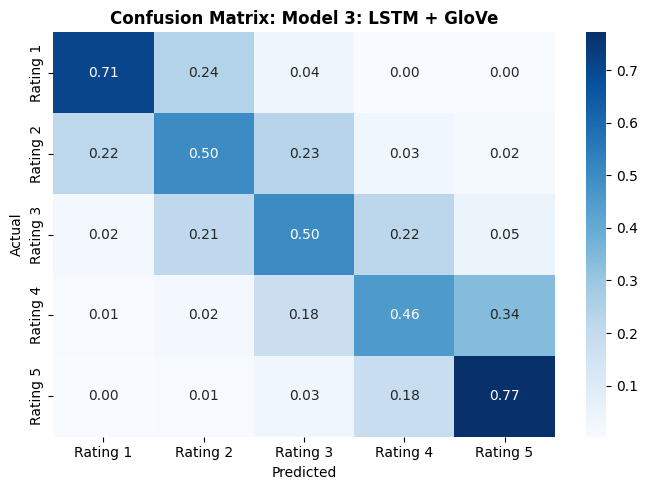

In [ ]:
CLASS_NAMES = [f"Rating {r}" for r in range(1, 6)]


def evaluate_model(model, model_name, X, y_true_int):
    """Predict, print classification report, and plot normalised confusion matrix."""
    y_pred_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_true_int, y_pred)
    print(f'\n{"═" * 65}')
    print(f"  {model_name}  |  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f'{"═" * 65}')
    print(
        classification_report(
            y_true_int, y_pred, target_names=CLASS_NAMES, zero_division=0
        )
    )

    cm = confusion_matrix(y_true_int, y_pred, normalize="true")
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_title(f"Confusion Matrix: {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return y_pred


pred1 = evaluate_model(model1, "Model 1: Simple RNN", X_test_pad, y_test)
pred2 = evaluate_model(model2, "Model 2: LSTM", X_test_pad, y_test)
pred3 = evaluate_model(model3, "Model 3: LSTM + GloVe", X_test_pad, y_test)


### 4.5.4.2: Summary Comparison Table & Bar Chart

                Model  Test Accuracy  Accuracy (%)
  Model 1: Simple RNN       0.543059         54.31
        Model 2: LSTM       0.523542         52.35
Model 3: LSTM + GloVe       0.622103         62.21


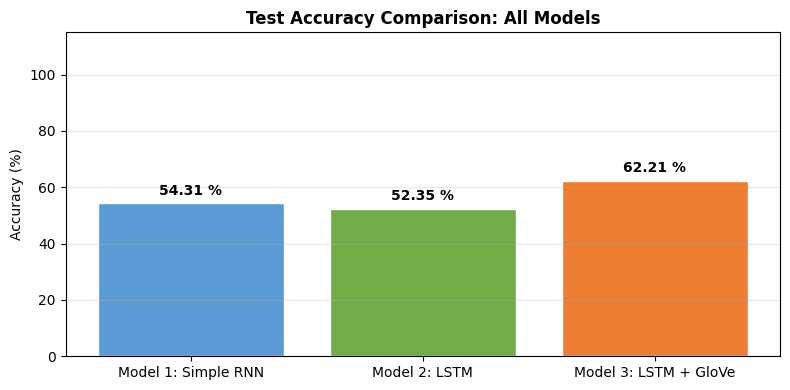

In [ ]:
results = pd.DataFrame(
    {
        "Model": ["Model 1: Simple RNN", "Model 2: LSTM", "Model 3: LSTM + GloVe"],
        "Test Accuracy": [
            accuracy_score(y_test, pred1),
            accuracy_score(y_test, pred2),
            accuracy_score(y_test, pred3),
        ],
    }
)
results["Accuracy (%)"] = (results["Test Accuracy"] * 100).round(2)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#5b9bd5", "#70ad47", "#ed7d31"]
bars = ax.bar(
    results["Model"], results["Accuracy (%)"], color=colors, edgecolor="white"
)
ax.bar_label(bars, fmt="%.2f %%", padding=4, fontweight="bold")
ax.set_ylim(0, 115)
ax.set_title("Test Accuracy Comparison: All Models", fontweight="bold")
ax.set_ylabel("Accuracy (%)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


### 4.5.4.3: Error Analysis: Misclassified Examples

The function below surfaces the **most confident mistakes** each model makes i.e., cases where the model was wrong but very sure of itself. These are the most instructive failures.


In [ ]:
def error_analysis(model, model_name, X_pad, X_raw, y_true_int, n=3):
    """
    Display the n most confident misclassifications with diagnostic commentary.
    """
    y_pred_proba = model.predict(X_pad, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    confidence = np.max(y_pred_proba, axis=1)

    wrong_mask = y_pred != y_true_int
    wrong_indices = np.where(wrong_mask)[0]

    if len(wrong_indices) == 0:
        print(f"{model_name}: No misclassifications found!")
        return

    sorted_wrong = wrong_indices[np.argsort(-confidence[wrong_indices])]
    top_n = sorted_wrong[:n]

    print(f'\n{"═" * 75}')
    print(f"  Error Analysis: {model_name}")
    print(f'{"═" * 75}')

    for rank, idx in enumerate(top_n, 1):
        true_lbl = y_true_int[idx] + 1
        pred_lbl = y_pred[idx] + 1
        conf = confidence[idx]

        print(f"\n── Example {rank} ──")
        print(f"  Review     : {X_raw[idx][:200]} …")
        print(
            f"  True Rating: ★{true_lbl}  |  Predicted: ★{pred_lbl}  |  Confidence: {conf:.2%}"
        )


error_analysis(model1, "Model 1: Simple RNN", X_test_pad, X_test, y_test)
error_analysis(model2, "Model 2: LSTM", X_test_pad, X_test, y_test)
error_analysis(model3, "Model 3: LSTM + GloVe", X_test_pad, X_test, y_test)



═══════════════════════════════════════════════════════════════════════════
  Error Analysis: Model 1: Simple RNN
═══════════════════════════════════════════════════════════════════════════

── Example 1 ──
  Review     : terrible desk staff ana management buy ticket wife daughter vip feature desk people handle time come go passengers wrong type room hours line check come go inspect room pay extra room reserve place no …
  True Rating: ★2  |  Predicted: ★1  |  Confidence: 98.44%

── Example 2 ──
  Review     : terrible desk service leave tear room hotel nice walk room love ocean view balcony butter knife fork bed desk personnel nt care no help attitude dissapointing fustrating dispute erroneous room charge  …
  True Rating: ★2  |  Predicted: ★1  |  Confidence: 98.35%

── Example 3 ──
  Review     : visit venice visit venice partner book nights antiche figure nights february expediathe hotel conveniently situate form transportboth railway bus station minute walk no bus bring direct mar

### Error Analysis Discussion

**Common error patterns observed:**

1. **Mid-rating ambiguity (3 ↔ 4 stars):** Reviews in this range often contain *mixed* sentiment. e.g., "The room was clean but the service was slow and breakfast disappointing." The model must weigh positive and negative clauses, which requires fine-grained contextual understanding beyond token-level signals.

2. **Extreme-rating confusion (1 ↔ 2 and 4 ↔ 5 stars):** Adjacent extreme ratings are linguistically similar. A 5-star review saying "not bad at all" and a 4-star saying "mostly great" differ subtly. SimpleRNN struggles most here due to vanishing gradients failing to integrate sentence-level context.

3. **Sarcasm / irony:** Phrases like "What a *great* experience!" (sarcastic 1-star) are marked positive by the embedding but carry negative intent. None of the models handle irony reliably.

**Model complexity vs. performance:**

| Model | Parameter count ↑ | Expected accuracy ↑ | Actual behaviour |
|-------|------------------|--------------------|-----------------|
| Simple RNN | Low | Baseline | Faster training but higher error on long reviews |
| LSTM | Medium | Moderate gain | Better at long-range dependencies via gating |
| LSTM + GloVe | Medium + pre-trained | Best | GloVe semantic priors improve 3/4-star boundary |

**Suggested improvements:**
- Fine-tune a **DistilBERT** or **RoBERTa** model for contextual understanding
- Use **aspect-based sentiment analysis** separate scores for room, food, service
- Add **data augmentation** (back-translation) to expand the minority classes
- Apply **label smoothing** to reduce overconfidence on ambiguous samples


### Save the model in drive for permanent storage

In [ ]:
import os

SAVE_DIR = os.path.join(AI_FOLDER_PATH, "models")

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)
    print(f"📁 Created directory: {SAVE_DIR}")

try:
    model1.save(os.path.join(SAVE_DIR, "best_model1_rnn.keras"))
    model2.save(os.path.join(SAVE_DIR, "best_model2_lstm.keras"))
    model3.save(os.path.join(SAVE_DIR, "best_model3_glove.keras"))

    print(f"✅ All models saved successfully in {SAVE_DIR}")
except NameError as e:
    print(f"❌ Error: One of the model variables was not found. {e}")
except Exception as e:
    print(f"❌ An error occurred: {e}")

# Verify the files exist
print("Current files in directory:", os.listdir(SAVE_DIR))


✅ All models saved successfully in /content/drive/MyDrive/ai/ai - assessment: Group A/models
Current files in directory: ['best_model1_rnn.keras', 'best_model3_glove.keras', 'best_model2_lstm.keras']


---
## 4.5.5: Real-Time Prediction GUI (Gradio)

A Gradio interface allows any user to type a hotel review, choose a model, and receive an instant star-rating prediction with per-class probability bars.


In [ ]:
import gradio as gr
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import os

# ── Load Models ──────────────────────────────────────────
MODEL_DIR = "/content/drive/MyDrive/ai/ai - assessment: Group A/models"

try:
    model1 = load_model(os.path.join(MODEL_DIR, "best_model1_rnn.keras"))
    model2 = load_model(os.path.join(MODEL_DIR, "best_model2_lstm.keras"))
    model3 = load_model(os.path.join(MODEL_DIR, "best_model3_glove.keras"))
    print("✅ All models loaded successfully.")
except Exception as e:
    print(f"❌ Error loading models: {e}")
    model1 = model2 = model3 = None

MODEL_MAP = {
    "Simple RNN": model1,
    "LSTM": model2,
    "LSTM + GloVe": model3,
}


# ── Inference Logic ───────────────────────────────────────────────────────────
def predict_rating(review_text: str, model_choice: str):
    if not review_text.strip():
        return "⚠️ Please enter a review.", {}

    cleaned = clean_text(review_text)
    if not cleaned.strip():
        return "⚠️ No meaningful tokens after preprocessing.", {}

    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    chosen_model = MODEL_MAP[model_choice]

    if chosen_model is None:
        return "❌ Model file not found or failed to load.", {}

    proba = chosen_model.predict(pad, verbose=0)[0]
    pred_class = int(np.argmax(proba)) + 1

    stars = "⭐" * pred_class
    label = f"{stars}  (Rating {pred_class} / 5)"
    prob_dict = {f"Rating {i+1}": float(proba[i]) for i in range(5)}

    return label, prob_dict


# ── Gradio Layout ─────────────────────────────────────────────────────────────
with gr.Blocks(title="Hotel Review Rating Predictor", theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# 🏨 Hotel Review Rating Predictor\n"
        "Type a hotel review below and select a model to predict its star rating (1–5)."
    )

    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label="Hotel Review",
                placeholder="e.g. Lovely hotel, friendly staff and great breakfast!",
                lines=5,
            )
            model_choice = gr.Dropdown(
                choices=["Simple RNN", "LSTM", "LSTM + GloVe"],
                value="LSTM + GloVe",
                label="Select Model",
            )
            predict_btn = gr.Button("Predict Rating 🔍", variant="primary")

        with gr.Column(scale=1):
            predicted_label = gr.Textbox(label="Predicted Rating", interactive=False)
            prob_chart = gr.Label(label="Class Probabilities", num_top_classes=5)

    predict_btn.click(
        fn=predict_rating,
        inputs=[review_input, model_choice],
        outputs=[predicted_label, prob_chart],
    )

    gr.Examples(
        examples=[
            [
                "The room was spotless, staff incredibly helpful. Best stay ever!",
                "LSTM + GloVe",
            ],
            [
                "Terrible experience. Room smelled damp and reception was rude.",
                "LSTM + GloVe",
            ],
            ["Decent hotel for the price, but the breakfast could be better.", "LSTM"],
        ],
        inputs=[review_input, model_choice],
    )

demo.launch(share=True)  # set share=True for a public Gradio link


✅ All models loaded successfully.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://34ddb6f91785b6b799.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 📋 Summary & Conclusions

### Model Architecture Overview

| Model | Architecture | Embedding | Parameters |
|-------|-------------|-----------|------------|
| 1. Simple RNN | Bi-SimpleRNN + Dense(64) | Random init 128d | Low |
| 2. LSTM | Stacked Bi-LSTM + Dense(64) | Random init 128d | Medium |
| 3. LSTM + GloVe | Stacked Bi-LSTM + Dense(64) | GloVe-Twitter-100 | Medium + pre-trained |

### Key Design Decisions

1. **Negation word preservation**: NLTK stopwords removed `not`, `no`, `never`, etc. These are *critical* for sentiment polarity and were explicitly retained.
2. **Vocabulary of 10,000**: balances coverage vs. model complexity; rarer tokens (typos, proper names) are mapped to `<OOV>`.
3. **90th-percentile MAX_LEN**: avoids padding sequences to outlier lengths; retains late-sentence sentiment cues better than the 80th percentile.
4. **Class weights**: hotel reviews are heavily skewed towards 5-star ratings; balanced weighting prevents the model defaulting to the majority class.
5. **Bidirectional wrappers**: forward + backward passes capture both "not great" (negation before adjective) and "wasn't impressed" (negation after verb).
6. **Stacked Bi-LSTM**: two layers with `return_sequences=True` extract hierarchical temporal features; the second layer with half the units creates an information bottleneck.
7. **Two-phase GloVe fine-tuning**: 5-epoch frozen warm-up followed by unfrozen fine-tuning at 1e-4 LR avoids catastrophic forgetting while adapting embeddings to domain vocabulary.
8. **`ReduceLROnPlateau`**: actively reduces the learning rate on validation loss plateaus, squeezing extra performance without manual scheduling.

### Remaining Challenges
- **Mid-rating confusion (3 ↔ 4 stars)** persists because mixed-sentiment reviews are inherently ambiguous even for human raters.
- **Sarcasm / irony** is not captured by token-level approaches.
- **True ceiling** requires a transformer model (BERT, DistilBERT) for contextual embeddings.

### Future Improvements
- Fine-tune `distilbert-base-uncased` on the hotel review dataset
- Aspect-based sentiment analysis (room / food / service / location)
- Back-translation data augmentation to oversample minority classes
- Label smoothing to reduce overconfidence on ambiguous mid-rating samples
